# Korean Name Sign Language (Challenge 3) — Client

What you fill in: `load_model()` and `run_inference(model, data)`. Everything else (registration, round tracking, submission) is provided.

**Prediction format**

- `prediction`: composed Korean name as a string (e.g. `"박상민"`),
  or a dict like `{"current_char":"민","composed_text":"박상민"}`.
- `visualizations`: format-free (PIL Image recommended for the dashboard)


**Workflow**
1. TA gives you `SERVER_URL` and your `TEAM_SECRET` (one per team).
2. Run the registration cell — the client exchanges the secret for a session token automatically.
3. When the TA calls `start_round(r)`, you call `process_round()`.


In [ ]:
# 1. Dependencies (Colab 전용 — 최초 1회 실행 후 런타임 재시작)
import sys, os

try:
    import google.colab
    _IN_COLAB = True
except ImportError:
    _IN_COLAB = False

if _IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

    DRIVE_BASE = '/content/drive/MyDrive/dl_pj'

    # ── hamer 레포 클론 ─────────────────────────────────────────────────────
    if not os.path.exists('/content/hamer'):
        !git clone -q https://github.com/HwangGeumhwan/hamer.git /content/hamer
        !git clone -q https://github.com/ViTAE-Transformer/ViTPose.git /content/hamer/third-party/ViTPose
    else:
        print('✓ /content/hamer 이미 존재')

    # ── Drive → Colab 코드 동기화 ───────────────────────────────────────────
    # Drive/CODE/ 에는 install_colab.sh, 각종 .py 파일을 함께 올려두세요
    !mkdir -p /content/hamer/CODE
    !cp -r {DRIVE_BASE}/CODE/* /content/hamer/CODE/
    # 루트에서 import 되는 파일들은 /content/hamer/ 로 복사
    for _f in ['vitpose_model.py', 'train_hamer.py',
                'korean_name_postprocess.py', 'extract_hamer_features.py']:
        _src = f'/content/hamer/CODE/{_f}'
        _dst = f'/content/hamer/{_f}'
        if os.path.exists(_src) and not os.path.exists(_dst):
            import shutil; shutil.copy(_src, _dst)

    # ── Colab 전용 설치 스크립트 실행 (로컬 install_hamer.sh 와 버전 동일) ──
    !HAMER_DIR=/content/hamer bash /content/hamer/CODE/install_colab.sh

    print('
✓ 설치 완료 — 런타임을 재시작하세요 (런타임 → 런타임 재시작)')


In [ ]:
!apt-get install -qq fonts-nanum
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import requests, base64, io, os, glob
from PIL import Image

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)


plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

Selecting previously unselected package fonts-nanum.
(Reading database ... 118252 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


In [ ]:
# 2. Configuration

# [NOTICE] The SERVER_URL and TEAM_SECRET will be provided by the TA on the demo day.
# This link and token are just for practice.
# URL Updated (2026.05.20)
SERVER_URL  = 'https://integrity-microwave-defeat-developing.trycloudflare.com' # from TA (Click this link to visit the demo page)
TEAM_SECRET = 'secret_team12_only' # Please enter only your team's token. (ex. secret_team12_only)

#TEAM_SECRETS = {
#    'secret_team12_only': 'team12',
#    'secret_team5_only': 'team5',
#    'secret_team20_only': 'team20',
#    'secret_team10_only': 'team10',
#    'secret_team4_only': 'team4',
#}

KOR_CONSONANTS = ['ㄱ','ㄴ','ㄷ','ㄹ','ㅁ','ㅂ','ㅅ','ㅇ','ㅈ','ㅊ','ㅋ','ㅌ','ㅍ','ㅎ']
KOR_VOWELS     = ['ㅏ','ㅐ','ㅑ','ㅒ','ㅓ','ㅔ','ㅕ','ㅖ','ㅗ','ㅛ','ㅜ','ㅠ','ㅡ','ㅢ','ㅣ','ㅘ','ㅝ']
ALL_JAMO = KOR_CONSONANTS + KOR_VOWELS

# For practice: You can upload your own collected test image/sequence data
# to the following path (eval/latest/) to test your model freely before the demo.
# On the demo day, this path might be updated to point to the official evaluation set.
TEST_DATA_DIR = '/content/drive/MyDrive/dl_challenge1/eval/' # (example)

# 모델 경로 (Drive에 업로드한 경로로 수정)
MLP_PATH      = '/content/drive/MyDrive/dl_pj/model/gesture_mlp.pth'
RESCALE_FACTOR = 2.0


In [ ]:
# 3. Register with the server (run once per session)

# Module-level token storage; submit_to_server() picks it up automatically.
_session_token = None
_team_id = None

def register():
    global _session_token, _team_id
    r = requests.post(f'{SERVER_URL}/register', json={'secret': TEAM_SECRET}, timeout=10)
    if r.status_code == 401:
        raise RuntimeError('TEAM_SECRET is invalid. Ask the TA for the correct secret.')
    r.raise_for_status()
    data = r.json()
    _session_token = data['token']
    _team_id = data['team']
    print(f'Registered as {_team_id} (token reused: {data["reused"]})')
    return _team_id

register()


Registered as team12 (token reused: True)


'team12'

In [ ]:
# 5. Drive는 Cell 1에서 이미 마운트됨
print("✓ Drive already mounted at /content/drive")


In [ ]:
# 6. Load your model — HaMeR + Detectron2 + ViTPose + MLP 전체 로드
import sys, time
import torch, joblib
import numpy as np
from pathlib import Path

# Colab 경로 설정
for _p in ['/content/hamer', '/content/hamer/CODE']:
    if _p not in sys.path:
        sys.path.insert(0, _p)

from hamer.configs import CACHE_DIR_HAMER
from hamer.models import download_models, load_hamer, DEFAULT_CHECKPOINT
from hamer.utils.utils_detectron2 import DefaultPredictor_Lazy
from vitpose_model import ViTPoseModel
import torch.nn as nn

class GestureMLP(nn.Module):
    def __init__(self, input_dim=37, hidden_dim=64, fc_dim=32, num_classes=31, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, fc_dim),    nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(fc_dim, num_classes),
        )
    def forward(self, x): return self.net(x)


def load_model():
    t0 = time.perf_counter()
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f'Device: {device}')

    # HaMeR
    download_models(CACHE_DIR_HAMER)
    hamer_model, model_cfg = load_hamer(DEFAULT_CHECKPOINT, init_renderer=False)
    hamer_model = hamer_model.to(device).eval()
    print(f'  HaMeR 로드          {time.perf_counter()-t0:.1f}s'); t0 = time.perf_counter()

    # Detectron2 (regnety — 빠른 옵션)
    from detectron2 import model_zoo
    det_cfg = model_zoo.get_config(
        'new_baselines/mask_rcnn_regnety_4gf_dds_FPN_400ep_LSJ.py', trained=True)
    det_cfg.model.roi_heads.box_predictor.test_score_thresh = 0.5
    det_cfg.model.roi_heads.box_predictor.test_nms_thresh   = 0.4
    detector = DefaultPredictor_Lazy(det_cfg)
    print(f'  Detectron2 로드     {time.perf_counter()-t0:.1f}s'); t0 = time.perf_counter()

    # ViTPose
    cpm = ViTPoseModel(device)
    print(f'  ViTPose 로드        {time.perf_counter()-t0:.1f}s'); t0 = time.perf_counter()

    # MLP 분류기
    ckpt      = torch.load(MLP_PATH, map_location=device)
    input_dim = ckpt['net.0.weight'].shape[1]
    mlp       = GestureMLP(input_dim=input_dim).to(device)
    mlp.load_state_dict(ckpt)
    mlp.eval()
    scaler_path = Path(MLP_PATH).parent / 'scaler.pkl'
    scaler = joblib.load(scaler_path) if scaler_path.exists() else None
    print(f'  MLP 로드            {time.perf_counter()-t0:.1f}s  (input_dim={input_dim})')

    return dict(hamer=hamer_model, model_cfg=model_cfg,
                detector=detector, cpm=cpm,
                mlp=mlp, scaler=scaler, device=device)


model = load_model()


In [ ]:
# 7. Inference — 이미지 시퀀스 → 자모 분류 → 한글 조합
import cv2, io, time
from PIL import Image

from extract_hamer_features import detect_hands, _vector_normalization_3d, ACTIONS
from hamer.utils import recursive_to
from hamer.datasets.vitdet_dataset import ViTDetDataset
from korean_name_postprocess import parse_jamo_to_korean


def load_eval_data():
    """TEST_DATA_DIR 안의 이미지를 숫자 순서로 반환."""
    import glob
    files = glob.glob(TEST_DATA_DIR + '*.png') + glob.glob(TEST_DATA_DIR + '*.jpg')
    return sorted(files, key=lambda p: int(Path(p).stem))


def _extract_26d(feat_75):
    vectors = feat_75[:60].reshape(20, 3)
    angles  = feat_75[60:]
    return np.concatenate([
        angles[0:3], angles[3:5], angles[6:8], angles[9:11], angles[12:14],
        vectors[3], vectors[7], vectors[11], vectors[15], vectors[19],
    ]).astype(np.float32)


def _fingertip_dists(kp3d):
    scale = np.linalg.norm(kp3d[9] - kp3d[12]) + 1e-8
    return np.array([
        np.linalg.norm(kp3d[8]  - kp3d[12]) / scale,
        np.linalg.norm(kp3d[12] - kp3d[16]) / scale,
    ], dtype=np.float32)


def classify_jamo(image_path):
    """이미지 한 장 → (예측 자모, 신뢰도). 손 미검출 시 (None, 0)."""
    m   = model
    img = cv2.imread(str(image_path))
    if img is None:
        return None, 0.0

    bboxes, sides, _, _, _ = detect_hands(img, m['detector'], m['cpm'])
    if bboxes is None:
        return None, 0.0
    right_mask = sides == 1
    if not right_mask.any():
        return None, 0.0

    r_bboxes = bboxes[right_mask][:1]
    r_sides  = sides[right_mask][:1]
    dataset  = ViTDetDataset(m['model_cfg'], img, r_bboxes, r_sides,
                              rescale_factor=RESCALE_FACTOR)
    batch = recursive_to(next(iter(
        torch.utils.data.DataLoader(dataset, batch_size=1, shuffle=False, num_workers=0)
    )), m['device'])

    with torch.no_grad():
        out = m['hamer'](batch)

    kp3d          = out['pred_keypoints_3d'][0].detach().cpu().numpy()
    global_orient = (out['pred_mano_params']['global_orient'][0]
                     .detach().cpu().numpy().reshape(9).astype(np.float32))
    vectors, angles = _vector_normalization_3d(kp3d)
    feat75 = np.concatenate([vectors.flatten(), angles.flatten()])
    feat   = np.concatenate([_extract_26d(feat75), global_orient,
                              _fingertip_dists(kp3d)]).astype(np.float32)

    del out, batch
    torch.cuda.empty_cache()

    scaler = m['scaler']
    if scaler is not None:
        feat = scaler.transform(feat[None])[0].astype(np.float32)
    with torch.no_grad():
        probs = torch.softmax(
            m['mlp'](torch.from_numpy(feat[None]).to(m['device'])), dim=1
        )[0].cpu().numpy()
    idx = int(probs.argmax())
    return ACTIONS[idx], float(probs[idx])


def run_inference():
    image_paths = load_eval_data()
    t0 = time.perf_counter()

    pred_jamos, confs = [], []
    for i, img_path in enumerate(image_paths):
        t_img = time.perf_counter()
        jamo, conf = classify_jamo(img_path)
        elapsed_ms = (time.perf_counter() - t_img) * 1000
        if jamo is None:
            print(f'  [{i:02d}] {Path(img_path).name:<10} 미검출  {elapsed_ms:.0f}ms')
            continue
        pred_jamos.append(jamo)
        confs.append(conf)
        print(f'  [{i:02d}] {Path(img_path).name:<10} → {jamo}  conf={conf*100:.1f}%  {elapsed_ms:.0f}ms')

    composed_text = parse_jamo_to_korean(pred_jamos) if pred_jamos else ''
    current_char  = pred_jamos[-1] if pred_jamos else ''
    total_elapsed = time.perf_counter() - t0
    print(f'\n  → {composed_text}  ({len(pred_jamos)}자모, {total_elapsed:.2f}s)')

    # ── 시각화 ─────────────────────────────────────────────────────────────────
    fig, (ax_text, ax_img) = plt.subplots(
        nrows=2, ncols=1, figsize=(6, 6),
        gridspec_kw={'height_ratios': [1, 3]})
    fig.patch.set_facecolor('#1a1d24')

    ax_text.set_facecolor('#1a1d24')
    ax_text.axis('off')
    ax_text.text(0.25, 0.65, f"Current: '{current_char}'",
                 ha='center', va='center', fontsize=22,
                 color='#fbbc04', fontweight='bold')
    ax_text.text(0.75, 0.65, f"Name: {composed_text}",
                 ha='center', va='center', fontsize=22,
                 color='#7ee399', fontweight='bold')

    ax_img.set_facecolor('#1a1d24')
    ax_img.axis('off')
    if image_paths:
        img = Image.open(image_paths[-1])
        ax_img.imshow(img)
    else:
        ax_img.text(0.5, 0.5, 'No image', ha='center', va='center', color='#9aa0a6')

    plt.tight_layout()
    buf = io.BytesIO()
    plt.savefig(buf, format='png', bbox_inches='tight', facecolor=fig.get_facecolor())
    plt.close(fig)
    buf.seek(0)

    prediction_data = {
        'current_char':  current_char,
        'composed_text': composed_text,
    }
    return prediction_data, Image.open(buf)


In [ ]:
# Submission helper (token-based, viz auto-encoded)

def _encode_viz(image):
    """Accepts PIL Image / numpy ndarray / base64 str / None."""
    if image is None:
        return None
    if isinstance(image, str):
        return image
    try:
        from PIL import Image
        if not isinstance(image, Image.Image):
            import numpy as np
            arr = image
            if arr.dtype != 'uint8':
                arr = (arr * 255).clip(0, 255).astype('uint8')
            image = Image.fromarray(arr)
        if max(image.size) > 640:
            ratio = 640 / max(image.size)
            image = image.resize((int(image.size[0]*ratio), int(image.size[1]*ratio)))
        buf = io.BytesIO()
        image.save(buf, format='PNG', optimize=True)
        return base64.b64encode(buf.getvalue()).decode('ascii')
    except Exception as e:
        print(f'[viz encode failed] {e}')
        return None

def submit_to_server(prediction, viz_image=None, timeout=10):
    if _session_token is None:
        raise RuntimeError('Not registered. Call register() first.')
    st = requests.get(f'{SERVER_URL}/api/state', timeout=5).json()
    round_id = st['current_round']
    if st['status'] != 'active':
        raise RuntimeError(f'Round {round_id} is {st["status"]} — cannot submit.')
    payload = {
        'round_id': round_id,
        'prediction': prediction,
        'viz_b64': _encode_viz(viz_image),
    }
    r = requests.post(
        f'{SERVER_URL}/submit',
        headers={'X-Team-Token': _session_token},
        json=payload, timeout=timeout,
    )
    if r.status_code == 423:
        raise RuntimeError(f'Round {round_id} closed (timer expired or TA closed it).')
    r.raise_for_status()
    return r.json()


In [ ]:
# Process one round
def process_round():
    """Run this function when the TA starts a new round."""
    pred, viz = run_inference()

    resp = submit_to_server(pred, viz_image=viz)
    print(f'[submitted] pred="{pred}" resp={resp}')
    return resp

In [ ]:
process_round()


[submitted] pred="{'current_char': 'ㄴ', 'composed_text': '박상민'}" resp={'count': 1, 'ok': True, 'round': 6, 'submission_mode': 'multiple', 'team': 'team12'}


{'count': 1,
 'ok': True,
 'round': 6,
 'submission_mode': 'multiple',
 'team': 'team12'}

#### Inference Upload Test Guide (practice mode only)


For testing purposes, the server will automatically run for 60 seconds each round, with a round interval of approximately 15 seconds. The Ground Truth (GT) will also loop randomly each round. Please ensure that your answers and visualization results are being uploaded successfully.

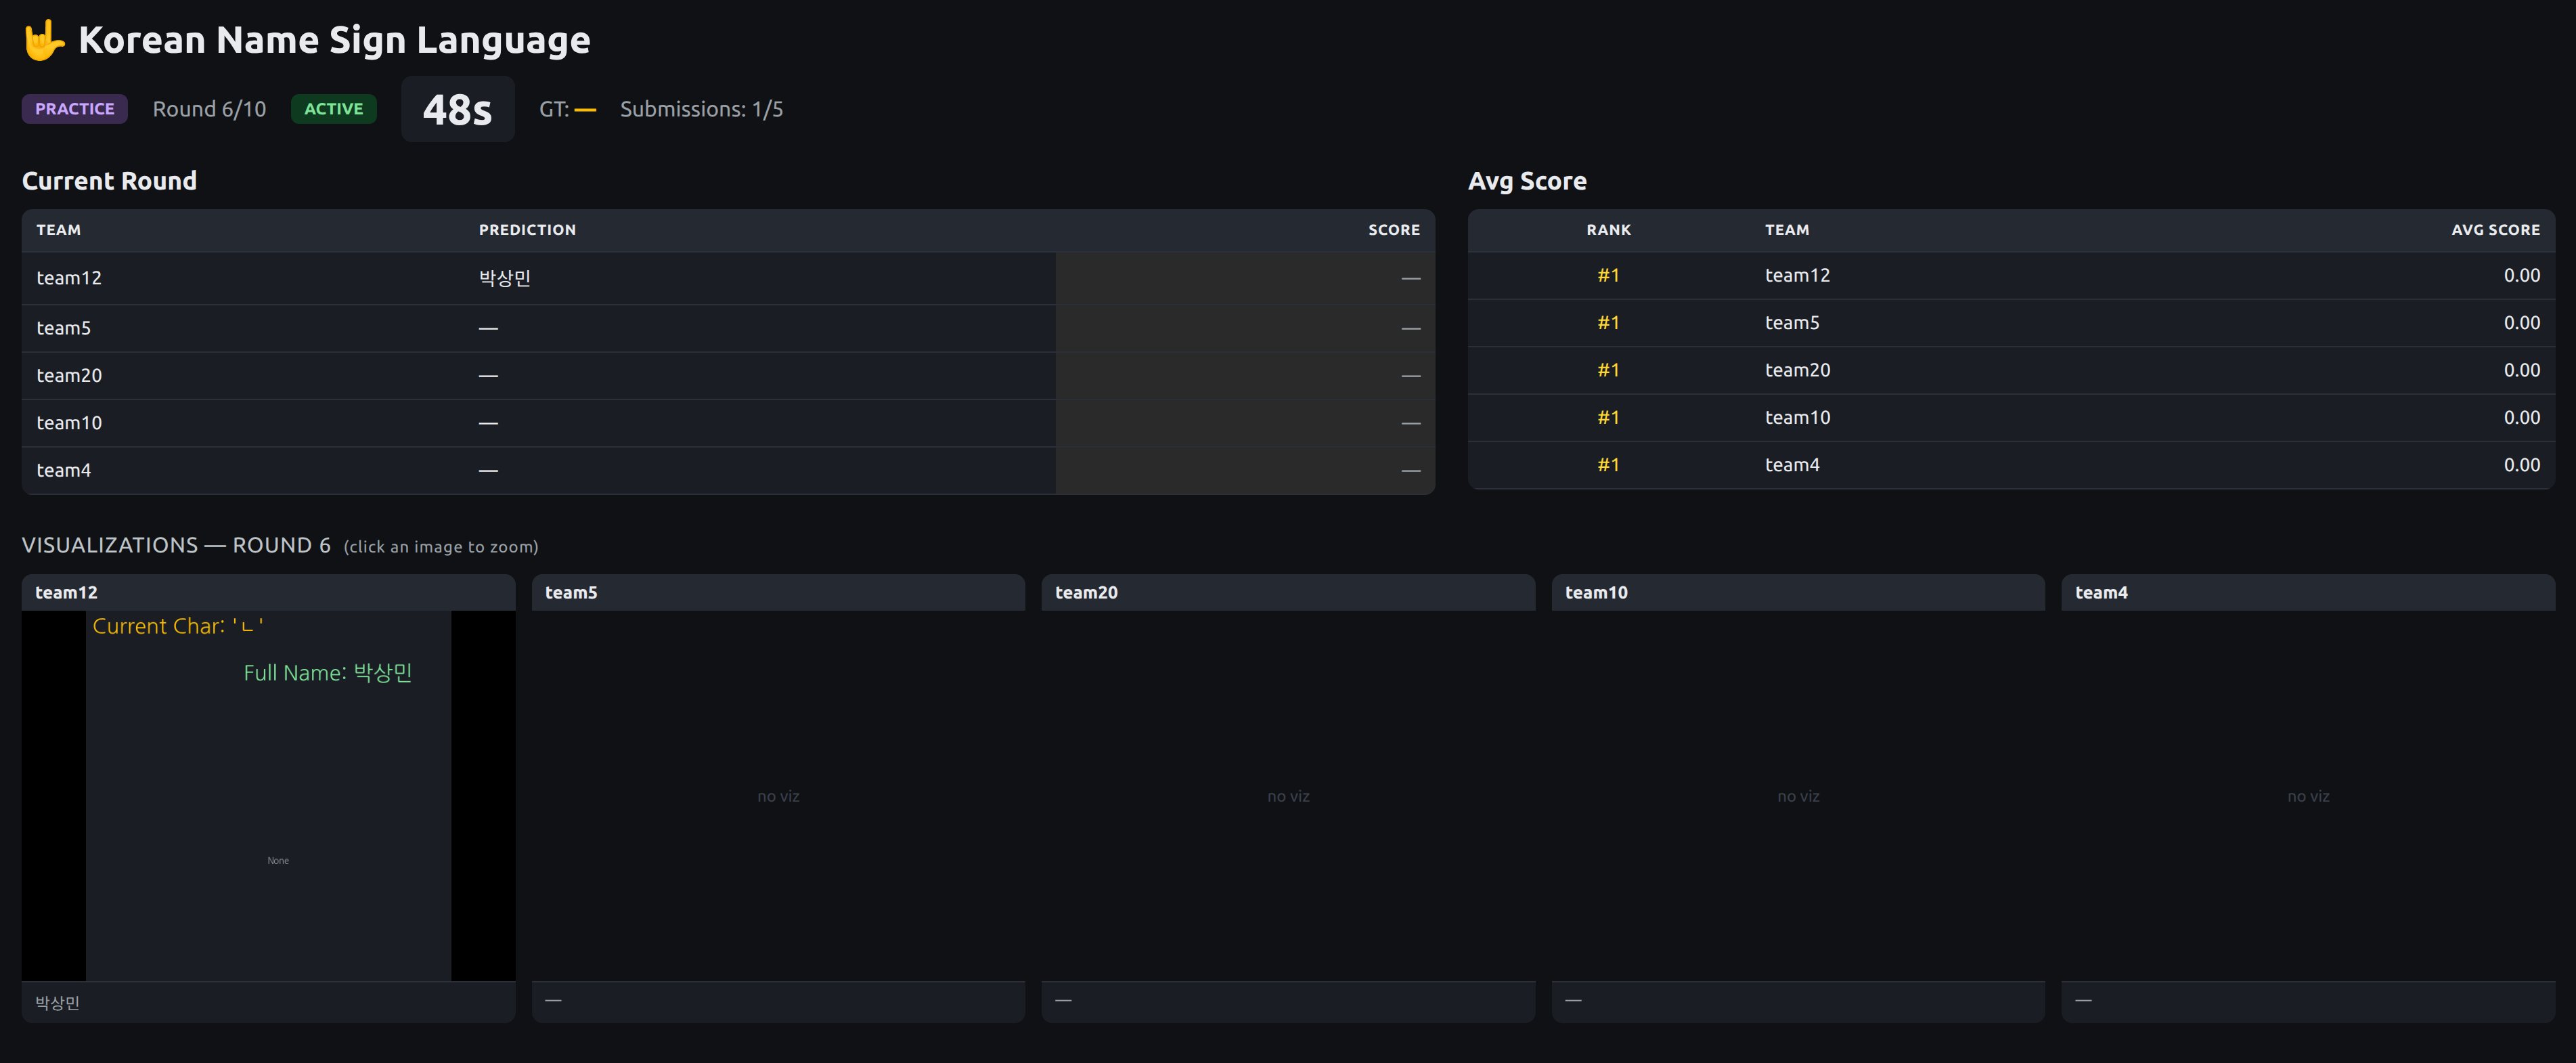